<a href="https://colab.research.google.com/github/erizz2/PHYS220-Project/blob/main/PHYS220proj_5-13-26_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

N = 100
M = 4000
h = 1.0
k = 0.25
r = 0.25


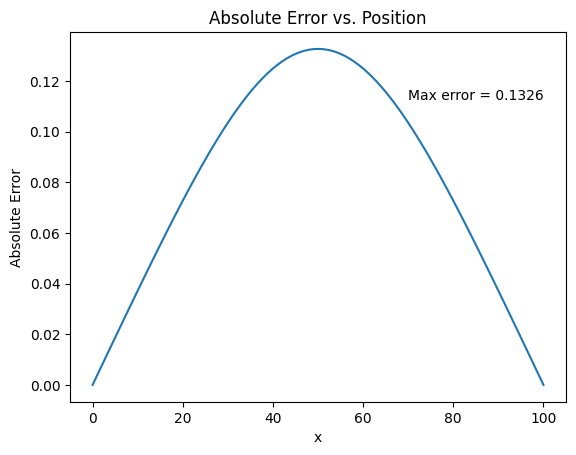

Max Error: 0.1326279581066956


In [15]:
from os import error
# import useful libraries
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import math
from scipy.integrate import quad
from IPython.display import HTML

# constants

# functions

def gaussian(x):
    '''
    This function returns a Gaussian profile.

    Parameters:
    x (float): The position.
    '''
    return 30000 * np.exp(-0.015*(x-50)**2)


def explicit_method(k, h, t_max, alpha, BC1, BC2, L):

    '''
    This function uses the explicit method of calculating the solution the the heat equation.

    Parameters:
    k (float): The time step.
    h (float): The spatial step.
    t_max (float): The maximum time.
    alpha (float): The thermal diffusivity.
    BC1 (float): The left boundary condition.
    BC2 (float): The right boundary condition.
    L (float): the length of the rod.
    '''

    M = int(t_max / k) # number of time steps
    N = int(L / h) # number of spatial steps
    u = np.zeros([N+1, M+1], float) # initalize solution variable
    x = np.linspace(0, L, N+1)

    u[:,0] = gaussian(x) # initial spatial profile


    # boundary conditions
    u[0, :] = BC1
    u[N, :] = BC2

    r = alpha * k / h**2


    print("N =", N)
    print("M =", M)
    print("h =", h)
    print("k =", k)
    print("r =", r)


    for n in range(M):
        for j in range(1, N):
            u[j, n+1] = (1 - 2*r)*u[j, n] + r*u[j-1, n] + r*u[j+1, n]

    return x, u

def implicit_method(k, h, t_max, alpha, BC1, BC2, L, target):

    '''
    This function uses the implicit method of calculating the solution the the heat equation.

    Parameters:
    k (float): The time step.
    h (float): The spatial step.
    t_max (float): The maximum time.
    T (float): The temperature.
    alpha (float): The thermal diffusivity.
    BC1 (float): The left boundary condition.
    BC2 (float): The right boundary condition.
    L = (float): the length of the rod.
    target (float): The accuracy condition.
    '''

    M = int(t_max / k) # number of time steps
    N = int(L / h) # number of spatial steps
    u = np.zeros([N+1, M+1], float) # initalize solution array
    x = np.linspace(0, L, N+1)

    u[:,0] = gaussian(x) # initial spatial profile


    # boundary conditions
    u[0, :] = BC1
    u[N, :] = BC2

    print("N =", N)
    print("M =", M)
    print("h =", h)
    print("k =", k)
    print("r =", r)

    r = alpha * k / h**2

    for n in range(M):
        u[:, n+1] = u[:, n]
        u[0, n+1] = BC1
        u[N, n+1] = BC2

        delta = 1.0

        while delta > target:

          for j in range(1, N):
            uprime = u[:, n+1].copy()

            u[j, n+1] = 1 / (1 + 2*r) * (u[j, n] + r*u[j-1, n+1] + r*u[j+1, n+1])
          delta = np.max(np.abs(uprime - u[:, n+1]))

    return x, u

def plot_numerical_vs_analytical_snapshots(x_vals, u, L, alpha, t_max):
    '''
    This function overlays numerical snapshots with the corresponding analytical solution.

    Parameters:
    x_vals (array): The spatial values.
    u (array): The numerical solution.
    L (float): The length of the rod.
    alpha (float): The thermal diffusivity.
    t_max (float): The maximum time.
    '''

    t_vals = np.linspace(0, t_max, u.shape[1])

    N_sol = 100
    B_list = compute_Bn_list(N_sol, L)

    time_indices = [0, 10, 50, 250, 500, 999]

    plt.figure()

    for t_index in time_indices:
        t = t_vals[t_index]

        # numerical solution at this time
        u_num = u[:, t_index]

        # analytical solution at this same time, evaluated on the same x grid
        u_exact = np.zeros(len(x_vals))
        for j, x in enumerate(x_vals):
            u_exact[j] = u_xt(x, t, L, alpha, B_list)

        plt.plot(x_vals, u_num, label=f"Numerical t={t:.2f}")
        plt.plot(x_vals, u_exact, "--", label=f"Analytical t={t:.2f}")

    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.title("Numerical vs Analytical Heat Equation Evolution")
    plt.legend()
    plt.show()
    return

def analytical_on_grid(x_vals, t, L, alpha):
    '''
    This function evaluates the analytical solution at one time t
    using the same x-values as the numerical solution.
    '''
    N_sol = 100
    B_list = compute_Bn_list(N_sol, L)

    u_exact = np.zeros(len(x_vals))

    for j, x in enumerate(x_vals):
        u_exact[j] = u_xt(x, t, L, alpha, B_list)

    return u_exact

def compute_error(x, u, u_exact):
    '''
    This function computes the error between the numerical and analytical solutions.

    Parameters:
    x (array): The spatial values.
    u_num (array): The numerical solution.
    u_exact (array): The analytical solution.
    '''
    err = np.abs(u-u_exact)
    max_err = np.max(err)

    plt.plot(x, err)
    plt.title("Absolute Error vs. Position")
    plt.text(0.70 * L, 0.85 * max_err, f"Max error = {max_err:.4f}")
    plt.xlabel("x")
    plt.ylabel("Absolute Error")
    plt.show()
    return max_err, err


def analytical_solution(L, alpha, t_max):
  '''
  This function computes the analytical solution for the heat equation, then plots it.

  Parameters:
  L (float): The length of the rod.
  alpha (float): The thermal diffusivity.
  '''
  t0= t_max # maximum time
  N_sol=100
  x_vals=np.linspace(0,L,500)
  t_vals=np.linspace(0,t0,1000)
  B_list=compute_Bn_list(N_sol,L)
  u_xt_array = np.zeros((len(t_vals),len(x_vals)))

  for i,t in enumerate(t_vals):
    for j,x in enumerate(x_vals):
      u_xt_array[i,j]=u_xt(x,t,L,alpha,B_list)

  # Plot a few time slices
  time_indices=[0,10,50,250,500,999]

  plt.figure()
  for t in time_indices:
    plt.plot(x_vals,u_xt_array[t,:],label=f"t={t_vals[t]:.2f}")
  plt.xlabel("x")
  plt.ylabel("u(x,t)")
  plt.title("Heat Equation Evolution (Snapshots)")
  plt.legend()
  plt.show()
  return

def simp(func,a,b,n,L):
  '''
  This function uses the Simpson's rule to compute the integral of a function.

  Parameters:
  func (function): The function to integrate.
  a (float): lower bound of integration
  b (float): upper bound of integration
  n (int): number of intervals
  L (float): length of rod
  '''

  N_simp=1000
  if N_simp%2==1:
    N_simp+=1
  h=(b-a)/N_simp
  evens=0
  odds=0
  for k in range(1,N_simp):
    xk=a+(k*h)
    if k%2==0:
      evens+=func(n,xk,L)
    else:
      odds += func(n,xk,L)
  return (1/3)*h*(func(n,a,L)+func(n,b,L)+(4*odds)+(2*evens))

def B_n(n,L):
  '''
  This function computes the Fourier sine series coefficients for the analytical solution to the heat equation.

  Paramters:
  n (int): The order of the Fourier sine series.
  L (float): The length of the rod.
  '''
  return (2/L)*simp(func,0,L,n,L)

def func(n,x,L):
  '''
  ???
  '''
  return (gaussian(x)*np.sin((n*np.pi*x)/L))

def compute_Bn_list(N,L):
  '''
  This function creates a list of the Fourier sine series coefficients for the analytical solution to the heat equation.

  Parameters:
  N (int): The order of the Fourier sine series.
  L (float): The length of the rod.
  '''
  B_vals = []
  for n in range(1, N + 1):
    B_vals.append(B_n(n, L))
  return B_vals

def u_xt(x,t,L,alpha,B_vals):
  '''
  ???
  '''
  total = 0

  for n,B in enumerate(B_vals,start=1):
    total+=B*np.sin((n*np.pi*x)/L)*np.exp(-alpha*(((n*np.pi)/L)**2)*t)

  return total


def plot_xt(u, L, t_max):
    plt.figure()
    plt.imshow(u, origin='lower', cmap='inferno', extent=[0,t_max,0,L]) # added extent to make sure t_max, L are constant
    plt.colorbar(label='Temperature (K)')
    plt.ylabel('x (m)')
    plt.xlabel('t (s)')
    plt.title("Heat vs. Time")
    plt.show()
    return


def plot_xt_stability(u, L, t_max):
    plt.figure()

    # mask the inf or nan values
    mask = np.ma.masked_invalid(u) # create a masked version of the solution array
    finite_vals = u[np.isfinite(u)] # check if each value in u is finite, if True, put into array

    # define min and max for the color bar
    vmin = np.percentile(finite_vals, 1)
    vmax = np.percentile(finite_vals, 99)

    plt.imshow(mask, origin='lower', cmap='inferno', aspect='auto',
               extent=[0, t_max, 0, L], vmin=vmin, vmax=vmax)

    plt.colorbar(label='Temperature (K)')
    plt.ylabel('Position x')
    plt.xlabel('Time t')
    plt.title("Heat vs. Time")
    plt.show()

def plot_time_evolution(u, L):
    fig, ax = plt.subplots()
    line, = ax.plot([], [])
    ax.set_xlabel("Position (m)")
    ax.set_ylabel("Temperature (K)")
    ax.set_xlim(0, L)
    ax.set_ylim(np.min(u), np.max(u)+1000) # added 1000 so the plot doesn't get cut off at the top

    def update(frame):
        line.set_data(x, u[:, frame])
        return line,


    ani = FuncAnimation(fig, update, frames = range(0, u.shape[1], 10), interval = 50, blit=False)


    plt.close(fig)
    display(HTML(ani.to_jshtml()))
    return

def plot_colorbar_time_evolution(u, L, t_max):
    fig, ax = plt.subplots(figsize=(10, 4))
    rod_data = u[:,0].reshape(1, -1)

    im = ax.imshow(rod_data, aspect=5.0, cmap='inferno', extent=[0,L,0,1]) # added extent here too

    time_text = ax.text(0.5*L, 0.01, '', fontsize=12, color='white') # multiply 0.5 by L to put label in middle of rod
    ax.set_yticks([])
    ax.set_xlabel("Position (m)")
    ax.set_title("1D Heat Equation Evolution")
    plt.colorbar(im, orientation='horizontal', label='Temperature (K)', pad=0.3)

    t_dim = u.shape[1]
    t_vals = np.linspace(0, t_max, t_dim) #added to work with fn params

    def update_color_bar(frame):
        step = frame # why not just delete this line and use frame?
        if step < u.shape[1]:
            new_data = u[:, step].reshape(1, -1)
            im.set_array(new_data)

            time_text.set_text(f"Timestep: {t_vals[step]}")

        return [im, time_text]

    ani = FuncAnimation(fig, update_color_bar, frames = range(0, u.shape[1], 10), interval=35, blit=True, repeat=True)

    plt.close(fig)
    display(HTML(ani.to_jshtml()))

def plot_3dmesh(u, L, t_max):
    fig = plt.figure()
    ax = plt.axes(projection='3d')

    x_dim, t_dim = u.shape

    x_vals = np.linspace(0, L, x_dim)
    t_vals = np.linspace(0, t_max, t_dim)

    T, X = np.meshgrid(t_vals, x_vals)

    ax.plot_surface(T, X, u, cmap='inferno')
    ax.set_title('Surface Plot')
    ax.set_xlabel('t (s)')
    ax.set_ylabel('x (m)')
    ax.set_zlabel('T (K)')
    plt.show()

    return


# main
if __name__ == "__main__":

    # Input params

    L = 100 # length of rod
    alpha = 1.0 # Thermal diffusivity
    t_max = 1000 # max time
    h = 1.0
    k = 0.25
    BC1 = 0.0 # Dirichlet BCs
    BC2 = 0.0


    # stability analysis
    '''
    time_step_values = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

    for time_step in time_step_values:
        x, u = explicit_method(time_step, 1.0, 1000, 1.0, 0.0, 0.0, 100)
        plot_3dmesh_stability(u, 100, 1000)
        plot_xt_stability(u,100, 1000)
    '''

    # accuracy testing
    '''
    # visually compare numerical vs analytical
    plot_numerical_vs_analytical_snapshots(x, u, L, alpha, t_max)


    # compute error
    x, u = explicit_method(k, h, t_max, alpha, BC1, BC2, L)
    u_final = u[:, -1] # final time step solution slice

    u_exact = analytical_on_grid(x, t_max, L, alpha) # analytical soln on the same grid as numerical soln
    max_err, err = compute_error(x, u_final, u_exact)
    print("Max Error:", max_err)
    '''




    # analytical solution
    '''
    analytical_solution(100, 0.1, 1000)
    analytical_solution(100,0.000014, 1000) #Quartz
    analytical_solution(100,0.00088, 1000) #silicon
    analytical_solution(100,0.00127, 1000) #gold


    # implicit method

    x, u = explicit_method(1.0, 3.0, 1000, 1.0, 0.0, 0.0, 100) # alpha is 1

    # plotting
    plot_xt(u, 100, 1000)
    plot_time_evolution(u, 100)
    plot_colorbar_time_evolution(u, 100, 1000)

    plot_3dmesh(u, 100, 1000)
    '''